<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Day_54_Batch_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Batch gradient descent is like normal gradient descent but in this chapter we will apply the gradient descent to N-dimensional data.

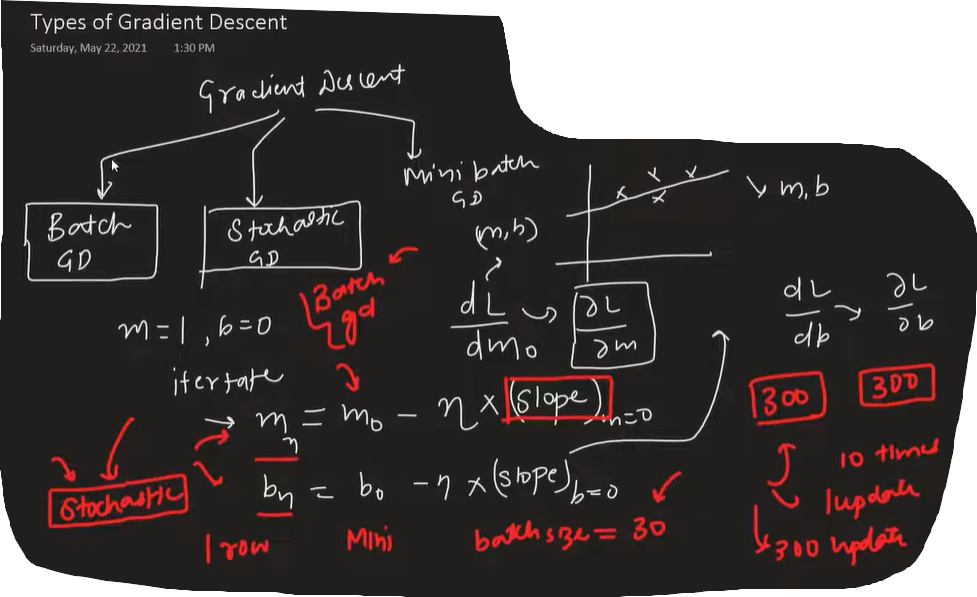

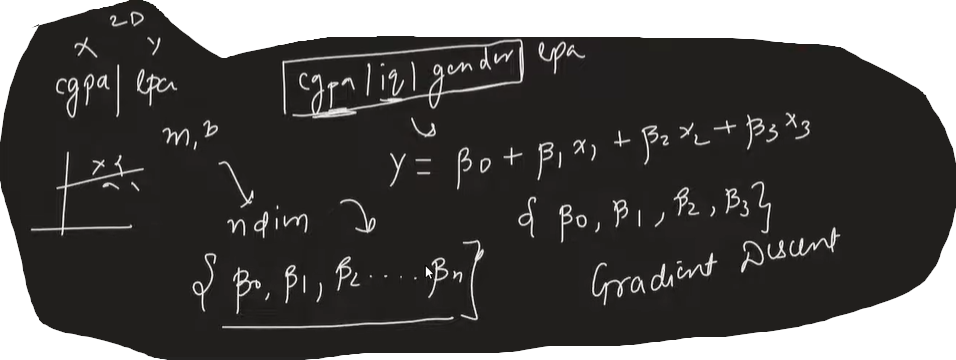

#**For N-Dim Data**

For 2 rows and 3 columns

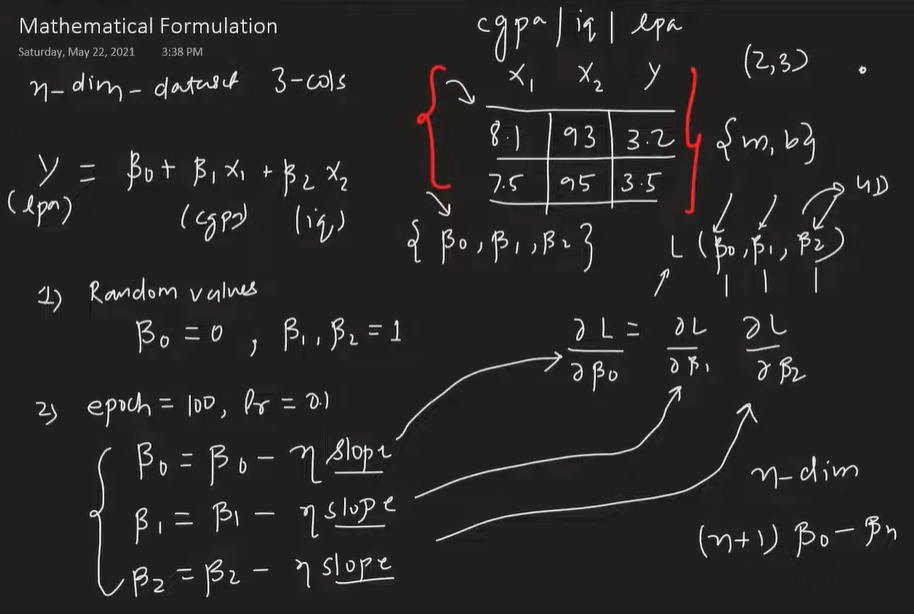

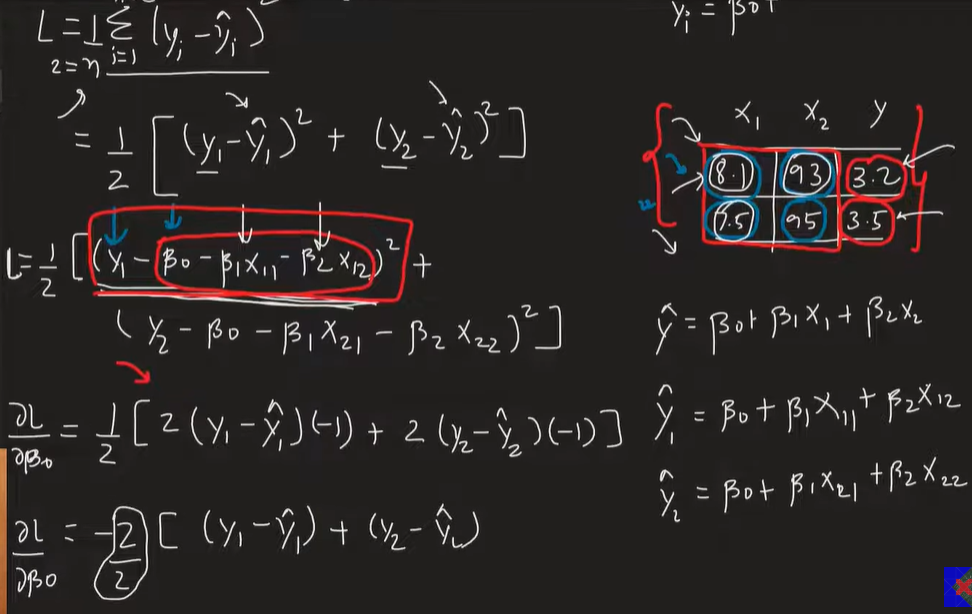

for n number of rows

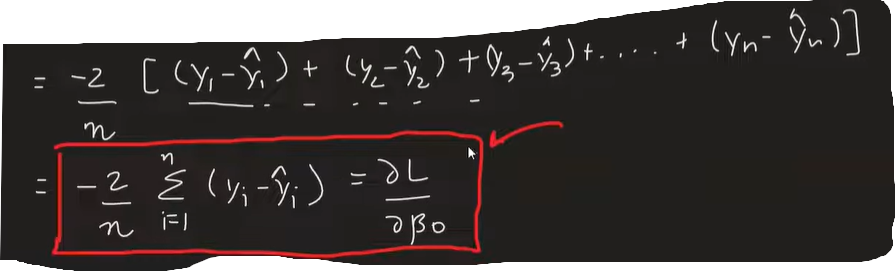

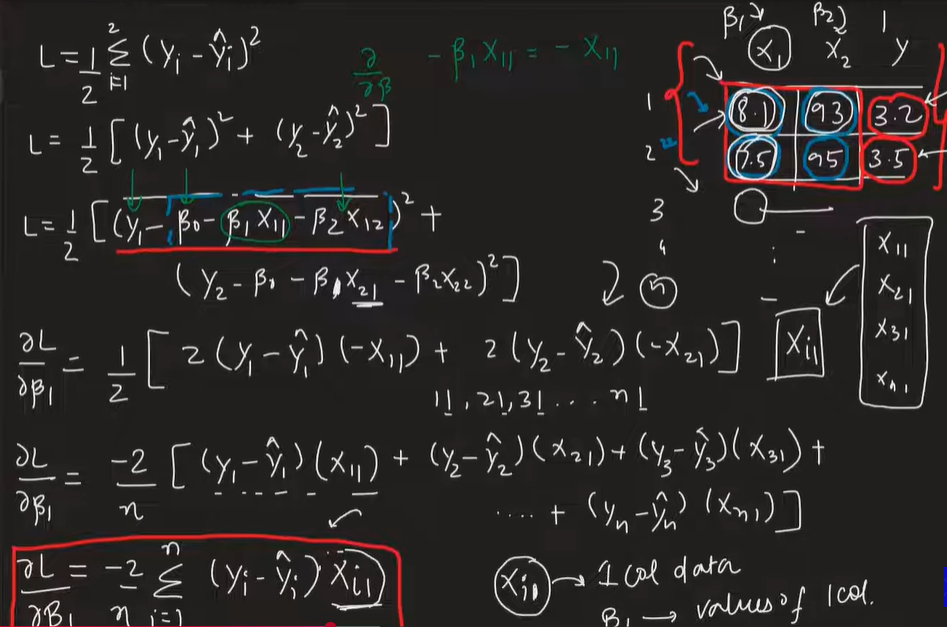

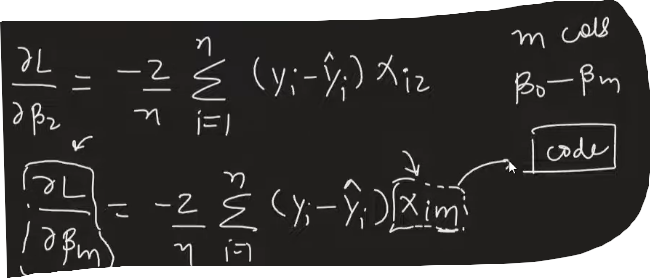

In [1]:
from sklearn.datasets import load_diabetes

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [3]:
X,y=load_diabetes(return_X_y=True)

In [4]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [27]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [28]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [29]:
X_train.shape

(353, 10)

#**Creating my own Gradient descent Class**

In [30]:
class GradientDescent:

  def __init__(self,learning_rate=0.01,epochs=100):
    self.lr=learning_rate
    self.epochs=epochs
    self.coef_=None
    self.intercept_=None

  def fit(self,X_train,y_train):
    # init your coef and intercept
    self.intercept_=0
    self.coef_=np.ones(X_train.shape[1])

    for i in range(self.epochs):
      # updating all intercept and coefficient
      y_hat= np.dot(X_train,self.coef_) + self.intercept_
      # finding the slope for intercept
      intercept_der=-2*np.mean(y_train-y_hat)
      #changing the intercept from old one
      self.intercept_=self.intercept_ + (self.lr*intercept_der)

      # finding the slope and changing the coeffiecent
      coef_der = -2 * np.dot((y_train - y_hat),X_train)/X_train.shape[0]
      self.coef_ = self.coef_ - (self.lr * coef_der)
    print(self.intercept_,self.coef_)


  def predict(self,X_test):
    return np.dot(X_test,self.coef_) + self.intercept_



In [59]:
gdr=GradientDescent(learning_rate=0.5,epochs=1000)

In [60]:
gdr.fit(X_train,y_train)

-1.5927150066904996e+303 [-1.51597383e+299 -2.27366485e+300 -3.24112764e+300 -5.36890485e+299
 -1.51223437e+300 -3.14373238e+300  3.65170078e+300 -4.26381755e+300
 -4.47779278e+299 -1.51201251e+300]


In [61]:
y_pred = gdr.predict(X_test)
r2_score(y_test,y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)


-inf